# Parking Space Box Classifier

This notebook trains a torchvision image classifier on parking-space crops from the COCO annotations in `data/train` and `data/valid`.

Use it when inference receives the full parking-lot image plus parking-space box annotations. The prediction helper accepts boxes without `category_id` and without `image_id`.

In [2]:
!pip install -r requirements.txt

  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparselt_cu12-0.6.2-py3-none-manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached nvidia_nccl_cu

In [17]:
from pathlib import Path
import json
import math
import random
import time
from collections import Counter, defaultdict

import numpy as np
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

print("torch", torch.__version__)
import torchvision
print("torchvision", torchvision.__version__)

torch 2.6.0+cu124
torchvision 0.21.0+cu124


## Configuration

Set `MAX_TRAIN_IMAGES` and `MAX_VALID_IMAGES` to an integer for a quicker experiment, or leave them as `None` to use every image in each split.

In [18]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

MAX_TRAIN_IMAGES = 1200
MAX_VALID_IMAGES = 1200
MAX_TEST_IMAGES = 300

# Training controls.
SEED = 42
INPUT_SIZE = 224
CROP_PADDING_RATIO = 0.08
BATCH_SIZE = 64
EPOCHS = 4
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED_BACKBONE = True
USE_CLASS_WEIGHTS = True

EARLY_STOP_PATIENCE = 2
EARLY_STOP_MIN_DELTA = 1e-4

CHECKPOINT_PATH = OUTPUT_DIR / "parking_space_box_classifier.pt"
CLASS_NAMES = ["space-empty", "space-occupied"]
CATEGORY_ID_TO_LABEL_INDEX = {1: 0, 2: 1}
LABEL_INDEX_TO_CATEGORY_ID = {v: k for k, v in CATEGORY_ID_TO_LABEL_INDEX.items()}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


In [19]:
def read_coco(split_dir: Path) -> dict:
    annotations_path = split_dir / "_annotations.coco.json"
    if not annotations_path.exists():
        raise FileNotFoundError(f"Missing annotation file: {annotations_path}")
    with annotations_path.open("r", encoding="utf-8") as f:
        return json.load(f)


def choose_images(images, max_images=None, seed=SEED):
    images = list(images)
    if max_images is None or max_images >= len(images):
        return images
    rng = random.Random(seed)
    selected = rng.sample(images, max_images)
    return sorted(selected, key=lambda item: item["id"])


def padded_xyxy_from_xywh(bbox, image_size, padding_ratio=CROP_PADDING_RATIO):
    image_width, image_height = image_size
    x, y, w, h = [float(value) for value in bbox]
    if w <= 0 or h <= 0:
        raise ValueError(f"Invalid bbox with non-positive size: {bbox}")
    pad_x = w * padding_ratio
    pad_y = h * padding_ratio
    x1 = max(0, int(math.floor(x - pad_x)))
    y1 = max(0, int(math.floor(y - pad_y)))
    x2 = min(image_width, int(math.ceil(x + w + pad_x)))
    y2 = min(image_height, int(math.ceil(y + h + pad_y)))
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid clipped bbox: {bbox}")
    return x1, y1, x2, y2


class CocoParkingBoxDataset(Dataset):
    def __init__(self, split_dir, max_images=None, transform=None, crop_padding_ratio=CROP_PADDING_RATIO):
        self.split_dir = Path(split_dir)
        self.transform = transform
        self.crop_padding_ratio = crop_padding_ratio

        coco = read_coco(self.split_dir)
        selected_images = choose_images(coco["images"], max_images=max_images)
        self.images_by_id = {image["id"]: image for image in selected_images}
        selected_image_ids = set(self.images_by_id)

        self.samples = []
        for ann in coco["annotations"]:
            image_id = ann.get("image_id")
            category_id = ann.get("category_id")
            if image_id not in selected_image_ids:
                continue
            if category_id not in CATEGORY_ID_TO_LABEL_INDEX:
                continue
            bbox = ann.get("bbox")
            if not bbox or len(bbox) != 4 or bbox[2] <= 0 or bbox[3] <= 0:
                continue
            self.samples.append((image_id, bbox, CATEGORY_ID_TO_LABEL_INDEX[category_id]))

        if not self.samples:
            raise ValueError(f"No usable box samples found in {self.split_dir}")

        self.labels = [label for _, _, label in self.samples]
        self.image_count = len(self.images_by_id)
        self.box_count = len(self.samples)
        self.class_counts = Counter(self.labels)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_id, bbox, label = self.samples[idx]
        image_record = self.images_by_id[image_id]
        image_path = self.split_dir / image_record["file_name"]
        image = Image.open(image_path).convert("RGB")
        crop_box = padded_xyxy_from_xywh(bbox, image.size, self.crop_padding_ratio)
        crop = image.crop(crop_box)
        if self.transform:
            crop = self.transform(crop)
        return crop, torch.tensor(label, dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = CocoParkingBoxDataset(DATA_DIR / "train", max_images=MAX_TRAIN_IMAGES, transform=train_transform)
valid_dataset = CocoParkingBoxDataset(DATA_DIR / "valid", max_images=MAX_VALID_IMAGES, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())

def print_dataset_summary(name, dataset):
    counts = {CLASS_NAMES[label]: dataset.class_counts.get(label, 0) for label in range(len(CLASS_NAMES))}
    print(f"{name}: {dataset.image_count:,} images, {dataset.box_count:,} boxes, class counts={counts}")

print_dataset_summary("train", train_dataset)
print_dataset_summary("valid", valid_dataset)

Task was destroyed but it is pending!
task: <Task pending name='Task-223' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-224' coro=<Kernel.shell_main() running at /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/ec2-user/anaconda3/envs/python3/lib/python3.12/collections/__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-224' coro=<Kernel.shell_main() running at /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


train: 1,200 images, 68,968 boxes, class counts={'space-empty': 36543, 'space-occupied': 32425}
valid: 1,200 images, 69,672 boxes, class counts={'space-empty': 36482, 'space-occupied': 33190}


In [20]:
def build_model(num_classes=len(CLASS_NAMES), use_pretrained=USE_PRETRAINED_BACKBONE):
    weights = models.ResNet18_Weights.DEFAULT if use_pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def class_weight_tensor(dataset):
    counts = torch.tensor([dataset.class_counts.get(i, 0) for i in range(len(CLASS_NAMES))], dtype=torch.float32)
    counts = torch.clamp(counts, min=1.0)
    weights = counts.sum() / (len(CLASS_NAMES) * counts)
    return weights


def confusion_metrics(confusion):
    confusion = confusion.float()
    total = confusion.sum().item()
    correct = confusion.diag().sum().item()
    accuracy = correct / total if total else 0.0

    precision_by_class = confusion.diag() / torch.clamp(confusion.sum(dim=0), min=1)
    recall_by_class = confusion.diag() / torch.clamp(confusion.sum(dim=1), min=1)
    f1_by_class = 2 * precision_by_class * recall_by_class / torch.clamp(precision_by_class + recall_by_class, min=1e-12)

    return {
        "accuracy": accuracy,
        "macro_precision": precision_by_class.mean().item(),
        "macro_recall": recall_by_class.mean().item(),
        "macro_f1": f1_by_class.mean().item(),
        "precision_by_class": precision_by_class.tolist(),
        "recall_by_class": recall_by_class.tolist(),
        "f1_by_class": f1_by_class.tolist(),
        "confusion_matrix": confusion.int().tolist(),
    }


def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0.0
    confusion = torch.zeros(len(CLASS_NAMES), len(CLASS_NAMES), dtype=torch.long)
    progress = tqdm(loader, desc=f"train epoch {epoch}")
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1).detach().cpu()
        for true_label, pred_label in zip(labels.detach().cpu(), preds):
            confusion[true_label, pred_label] += 1
        metrics = confusion_metrics(confusion)
        progress.set_postfix(loss=total_loss / max(1, confusion.sum().item()), acc=metrics["accuracy"])

    metrics = confusion_metrics(confusion)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, description="valid"):
    model.eval()
    total_loss = 0.0
    confusion = torch.zeros(len(CLASS_NAMES), len(CLASS_NAMES), dtype=torch.long)
    for images, labels in tqdm(loader, desc=description):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1).detach().cpu()
        for true_label, pred_label in zip(labels.detach().cpu(), preds):
            confusion[true_label, pred_label] += 1

    metrics = confusion_metrics(confusion)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


def format_metrics(prefix, metrics):
    return (
        f"{prefix}_loss={metrics['loss']:.4f} "
        f"{prefix}_acc={metrics['accuracy']:.4f} "
        f"{prefix}_macro_f1={metrics['macro_f1']:.4f} "
        f"{prefix}_macro_precision={metrics['macro_precision']:.4f} "
        f"{prefix}_macro_recall={metrics['macro_recall']:.4f}"
    )


model = build_model().to(DEVICE)
criterion_weight = class_weight_tensor(train_dataset).to(DEVICE) if USE_CLASS_WEIGHTS else None
criterion = nn.CrossEntropyLoss(weight=criterion_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable parameters: {trainable_params:,}")
if criterion_weight is not None:
    print("class weights:", {CLASS_NAMES[i]: round(float(w), 4) for i, w in enumerate(criterion_weight.detach().cpu())})

trainable parameters: 11,177,538
class weights: {'space-empty': 0.9437, 'space-occupied': 1.0635}


In [11]:
history = []
best_val_f1 = -1.0
epochs_without_improvement = 0
training_started = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_started = time.time()
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch)
    valid_metrics = evaluate(model, valid_loader, criterion, DEVICE, description=f"valid epoch {epoch}")

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["macro_f1"],
        "valid_loss": valid_metrics["loss"],
        "valid_accuracy": valid_metrics["accuracy"],
        "valid_f1": valid_metrics["macro_f1"],
        "seconds": time.time() - epoch_started,
    }
    history.append(row)

    print(
        f"epoch {epoch:02d} | "
        f"{format_metrics('train', train_metrics)} | "
        f"{format_metrics('valid', valid_metrics)} | "
        f"seconds={row['seconds']:.1f}"
    )
    print("valid confusion matrix rows=true cols=pred:", valid_metrics["confusion_matrix"])

    improved = valid_metrics["macro_f1"] > best_val_f1 + EARLY_STOP_MIN_DELTA
    if improved:
        best_val_f1 = valid_metrics["macro_f1"]
        epochs_without_improvement = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": CLASS_NAMES,
                "category_id_to_label_index": CATEGORY_ID_TO_LABEL_INDEX,
                "label_index_to_category_id": LABEL_INDEX_TO_CATEGORY_ID,
                "input_size": INPUT_SIZE,
                "crop_padding_ratio": CROP_PADDING_RATIO,
                "history": history,
                "best_epoch": epoch,
                "best_valid_f1": best_val_f1,
                "config": {
                    "max_train_images": MAX_TRAIN_IMAGES,
                    "max_valid_images": MAX_VALID_IMAGES,
                    "batch_size": BATCH_SIZE,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "use_pretrained_backbone": USE_PRETRAINED_BACKBONE,
                    "use_class_weights": USE_CLASS_WEIGHTS,
                },
            },
            CHECKPOINT_PATH,
        )
        print(f"saved new best checkpoint: {CHECKPOINT_PATH}")
    else:
        epochs_without_improvement += 1
        print(f"no improvement for {epochs_without_improvement} epoch(s)")

    if EARLY_STOP_PATIENCE is not None and epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"early stopping at epoch {epoch}; best F1={best_val_f1:.4f}")
        break

print(f"training seconds: {time.time() - training_started:.1f}")
print(f"best validation macro F1: {best_val_f1:.4f}")


train epoch 1:   0%|          | 0/1078 [00:00<?, ?it/s]

valid epoch 1:   0%|          | 0/1089 [00:00<?, ?it/s]

epoch 01 | train_loss=0.0820 train_acc=0.9699 train_macro_f1=0.9699 train_macro_precision=0.9695 train_macro_recall=0.9711 | valid_loss=0.0700 valid_acc=0.9744 valid_macro_f1=0.9744 valid_macro_precision=0.9742 valid_macro_recall=0.9752 | seconds=1096.4
valid confusion matrix rows=true cols=pred: [[34991, 1491], [291, 32899]]
saved new best checkpoint: /home/ec2-user/SageMaker/outputs/parking_space_box_classifier.pt


train epoch 2:   0%|          | 0/1078 [00:00<?, ?it/s]

valid epoch 2:   0%|          | 0/1089 [00:00<?, ?it/s]

...

valid epoch 3:   0%|          | 0/1089 [00:00<?, ?it/s]

epoch 03 | train_loss=0.0439 train_acc=0.9839 train_macro_f1=0.9839 train_macro_precision=0.9836 train_macro_recall=0.9843 | valid_loss=0.0637 valid_acc=0.9789 valid_macro_f1=0.9789 valid_macro_precision=0.9787 valid_macro_recall=0.9796 | seconds=1097.4
valid confusion matrix rows=true cols=pred: [[35227, 1255], [213, 32977]]
saved new best checkpoint: /home/ec2-user/SageMaker/outputs/parking_space_box_classifier.pt


train epoch 4:   0%|          | 0/1078 [00:00<?, ?it/s]

valid epoch 4:   0%|          | 0/1089 [00:00<?, ?it/s]

epoch 04 | train_loss=0.0323 train_acc=0.9887 train_macro_f1=0.9886 train_macro_precision=0.9884 train_macro_recall=0.9889 | valid_loss=0.0563 valid_acc=0.9842 valid_macro_f1=0.9842 valid_macro_precision=0.9839 valid_macro_recall=0.9847 | seconds=1081.0
valid confusion matrix rows=true cols=pred: [[35507, 975], [126, 33064]]
saved new best checkpoint: /home/ec2-user/SageMaker/outputs/parking_space_box_classifier.pt
training seconds: 4356.9
best validation macro F1: 0.9842


## Optional Test Evaluation

This loads the best checkpoint and evaluates it on `data/test`. Keep `MAX_TEST_IMAGES` small for a quick sanity check, or set it to `None`.

In [22]:
def load_checkpoint_model(checkpoint_path=CHECKPOINT_PATH, device=DEVICE):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    loaded_model = build_model(num_classes=len(checkpoint["class_names"]), use_pretrained=False).to(device)
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model.eval()
    return loaded_model, checkpoint


if CHECKPOINT_PATH.exists():
    best_model, checkpoint = load_checkpoint_model()
    test_dataset = CocoParkingBoxDataset(DATA_DIR / "test", max_images=MAX_TEST_IMAGES, transform=eval_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())
    print_dataset_summary("test", test_dataset)
    test_metrics = evaluate(best_model, test_loader, criterion, DEVICE, description="test")
    print(format_metrics("test", test_metrics))
    print("test confusion matrix rows=true cols=pred:", test_metrics["confusion_matrix"])
else:
    print(f"Checkpoint not found yet: {CHECKPOINT_PATH}")

test: 300 images, 17,260 boxes, class counts={'space-empty': 8561, 'space-occupied': 8699}


test:   0%|          | 0/270 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Predict From Image + Box Annotations

The helper below accepts a list of boxes without `category_id` or `image_id`. Supported input examples:

- `{"bbox": [x, y, width, height]}`
- `[x, y, width, height]`
- `{"x": x, "y": y, "width": width, "height": height}`
- `{"xmin": x1, "ymin": y1, "xmax": x2, "ymax": y2}` with `box_format="xyxy"`

In [7]:
def annotation_to_xywh(annotation, box_format="xywh"):
    if isinstance(annotation, dict):
        if "bbox" in annotation:
            values = annotation["bbox"]
            if len(values) != 4:
                raise ValueError(f"bbox must contain 4 values: {annotation}")
            if box_format == "xyxy":
                x1, y1, x2, y2 = [float(v) for v in values]
                return [x1, y1, x2 - x1, y2 - y1]
            return [float(v) for v in values]
        if {"x", "y", "width", "height"}.issubset(annotation):
            return [float(annotation["x"]), float(annotation["y"]), float(annotation["width"]), float(annotation["height"])]
        if {"xmin", "ymin", "xmax", "ymax"}.issubset(annotation):
            x1 = float(annotation["xmin"])
            y1 = float(annotation["ymin"])
            x2 = float(annotation["xmax"])
            y2 = float(annotation["ymax"])
            return [x1, y1, x2 - x1, y2 - y1]

    if isinstance(annotation, (list, tuple)) and len(annotation) == 4:
        values = [float(v) for v in annotation]
        if box_format == "xyxy":
            x1, y1, x2, y2 = values
            return [x1, y1, x2 - x1, y2 - y1]
        return values

    raise ValueError(f"Unsupported annotation format: {annotation}")


@torch.no_grad()
def predict_parking_boxes(image_path, box_annotations, checkpoint_path=CHECKPOINT_PATH, box_format="xywh", device=DEVICE):
    """Predict empty/occupied for supplied parking-space boxes.

    The incoming annotations do not need category_id or image_id. By default,
    list-style boxes are interpreted as COCO xywh: [x, y, width, height].
    """
    model, checkpoint = load_checkpoint_model(checkpoint_path=checkpoint_path, device=device)
    class_names = checkpoint["class_names"]
    label_index_to_category_id = checkpoint["label_index_to_category_id"]
    crop_padding_ratio = checkpoint.get("crop_padding_ratio", CROP_PADDING_RATIO)

    image = Image.open(image_path).convert("RGB")
    crops = []
    normalized_boxes = []
    for annotation in box_annotations:
        xywh = annotation_to_xywh(annotation, box_format=box_format)
        crop_box = padded_xyxy_from_xywh(xywh, image.size, crop_padding_ratio)
        crop = image.crop(crop_box)
        crops.append(eval_transform(crop))
        normalized_boxes.append(xywh)

    if not crops:
        return []

    batch = torch.stack(crops).to(device)
    logits = model(batch)
    probabilities = torch.softmax(logits, dim=1).detach().cpu()
    predicted_indices = probabilities.argmax(dim=1).tolist()

    results = []
    for annotation, xywh, pred_idx, probs in zip(box_annotations, normalized_boxes, predicted_indices, probabilities):
        confidence = float(probs[pred_idx])
        results.append(
            {
                "input_annotation": annotation,
                "bbox_xywh": [round(float(v), 3) for v in xywh],
                "predicted_label": class_names[pred_idx],
                "predicted_category_id": int(label_index_to_category_id[pred_idx]),
                "confidence": round(confidence, 6),
                "probabilities": {class_names[i]: round(float(probs[i]), 6) for i in range(len(class_names))},
            }
        )
    return results

## Final Demo: Random Test Image Prediction

This cell chooses one random image from `data/test`, pulls only its box coordinates, predicts each space, prints the empty/occupied totals, and displays the tested boxes over the image.

image: /home/ec2-user/SageMaker/data/test/2012-09-11_15_53_00_jpg.rf.8282544a640a23df05bd245a9210e663.jpg
boxes tested: 100
empty spaces: 29
occupied spaces: 71


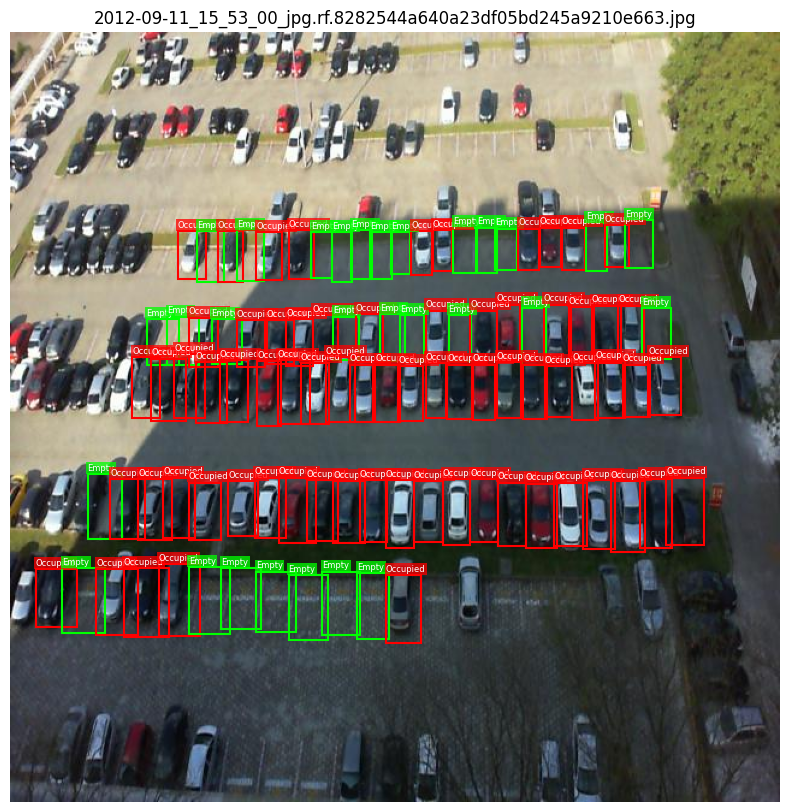

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

TEST_IMAGE_TO_PREDICT = "2012-09-11_15_53_00_jpg.rf.8282544a640a23df05bd245a9210e663.jpg"


def test_image_boxes(split_dir=DATA_DIR / "test", image_to_predict=None, seed=None):
    coco = read_coco(split_dir)
    annotations_by_image_id = defaultdict(list)
    for ann in coco["annotations"]:
        bbox = ann.get("bbox")
        if bbox and len(bbox) == 4 and bbox[2] > 0 and bbox[3] > 0:
            annotations_by_image_id[ann["image_id"]].append(ann)

    if image_to_predict is None:
        candidate_images = [img for img in coco["images"] if annotations_by_image_id.get(img["id"])]
        if not candidate_images:
            raise ValueError(f"No test images with box annotations found in {split_dir}")
        rng = random.Random(seed) if seed is not None else random
        image_record = rng.choice(candidate_images)
    else:
        requested_name = Path(image_to_predict).name
        matches = [img for img in coco["images"] if img["file_name"] == requested_name]
        if not matches:
            available = [img["file_name"] for img in coco["images"][:10]]
            raise ValueError(f"Image not found in test annotations: {requested_name}. First available images: {available}")
        image_record = matches[0]
        if not annotations_by_image_id.get(image_record["id"]):
            raise ValueError(f"Image has no usable box annotations: {requested_name}")
    image_path = split_dir / image_record["file_name"]

    # Pull only boxes for prediction. No category_id and no image_id are included.
    box_annotations = [{"bbox": ann["bbox"]} for ann in annotations_by_image_id[image_record["id"]]]
    return image_path, box_annotations


def display_prediction_boxes(image_path, predictions):
    image = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    ax.set_title(Path(image_path).name)
    ax.axis("off")

    for result in predictions:
        x, y, w, h = result["bbox_xywh"]
        label = result["predicted_label"]
        color = "lime" if label == "space-empty" else "red"
        short_label = "Empty" if label == "space-empty" else "Occupied"

        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=1.5))
        ax.text(
            x,
            max(0, y - 3),
            f"{short_label}",
            color="white",
            fontsize=6,
            bbox={"facecolor": color, "alpha": 0.75, "pad": 1, "edgecolor": "none"},
        )

    plt.show()


if not CHECKPOINT_PATH.exists():
    print(f"Checkpoint not found: {CHECKPOINT_PATH}")
    print("Run the training cell first so the best model checkpoint is available.")
else:
    test_image_path, test_box_annotations = test_image_boxes(image_to_predict=TEST_IMAGE_TO_PREDICT, seed=None)
    predictions = predict_parking_boxes(test_image_path, test_box_annotations)

    empty_spaces = sum(result["predicted_label"] == "space-empty" for result in predictions)
    occupied_spaces = sum(result["predicted_label"] == "space-occupied" for result in predictions)

    print(f"image: {test_image_path}")
    print(f"boxes tested: {len(test_box_annotations)}")
    print(f"empty spaces: {empty_spaces}")
    print(f"occupied spaces: {occupied_spaces}")

    display_prediction_boxes(test_image_path, predictions)

In [15]:
if CHECKPOINT_PATH.exists():
    best_model, checkpoint = load_checkpoint_model()

    path = OUTPUT_DIR / "bestModel.pt"
    
    torch.save(best_model, path)